# 08. Target & Deviation Analysis: How Do We Compare with Plan?
### Primary Analytical Purpose: *How does actual performance compare with a target or benchmark?*
**Lecture Reference:** Purpose 8 — Target / Deviation (Slides 37–40, 45)

Target and deviation analysis evaluates observed performance against an explicit goal, budget, forecast, or historical benchmark. It answers questions such as:
- Which units met or exceeded plan, and which experienced a shortfall?
- What is the magnitude and percentage size of each variance?
- Are misses systemic across the entire organization or localized to specific areas?

---

## 1. Scenario and Dataset Preview
**Business Scenario:** Commercial management evaluates Q4 revenue performance across 5 key commercial zones in Qatar: *West Bay*, *Lusail*, *The Pearl*, *Al Rayyan*, and *Al Wakrah*. Each zone had a pre-established quarterly revenue target (in millions of QAR).

The dataset is loaded from `data/qatar_zones_revenue_targets.csv`. Let us load it and calculate the variance metrics.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Set modern Seaborn theme
sns.set_theme(style="whitegrid")

# Load zone performance dataset
df = pd.read_csv("data/qatar_zones_revenue_targets.csv")

# Compute analytical variance columns
df["variance_qar"] = df["actual_million_qar"] - df["target_million_qar"]
df["pct_variance"] = (df["variance_qar"] / df["target_million_qar"]) * 100
df["miss"] = df["actual_million_qar"] < df["target_million_qar"]

# Display calculated table
df

,zone,target_million_qar,actual_million_qar,variance_qar,pct_variance,miss
0,West Bay,50.0,52.0,2.0,4.000000,False
1,Lusail,45.0,48.5,3.5,7.777778,False
2,The Pearl,40.0,34.8,-5.2,-13.000000,True
3,Al Rayyan,55.0,61.0,6.0,10.909091,False
4,Al Wakrah,35.0,34.0,-1.0,-2.857143,True


## 2. Primary Visualization: Actual-vs-Target Bar Chart (The Default)
- **What the chart shows:** Bars represent actual revenue; black horizontal tick lines (`—`) mark each zone's budget target.
- **When it is useful:** The clearest, most universally understood option for business stakeholders (Slide 37).
- **Lecture Implementation Note (Slide 39 & 40):**
  - **Show the target explicitly:** A bar alone cannot answer 'how did we compare to plan?'.
  - **Use a consistent colour rule:** Teal (`#14A098`) for met/exceeded target, coral red (`#D64545`) for a shortfall.
  - In Plotly, mixing bars and markers requires dropping from Plotly Express to `plotly.graph_objects`. Knowing when to leave the express API is a genuine skill!

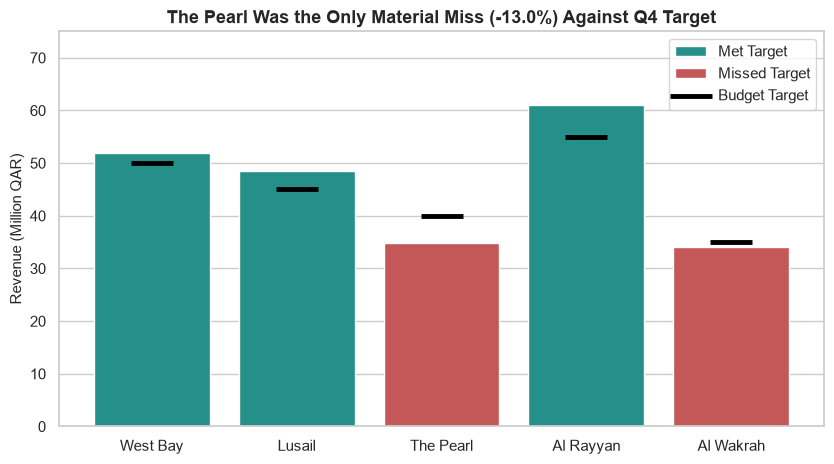

In [ ]:
# --- Seaborn Implementation: Bars with Scatter Target Markers ---
plt.figure(figsize=(8.5, 4.8))

# Plot actual bars colored conditionally by miss
palette = {False: "#14A098", True: "#D64545"}
ax = sns.barplot(
    data=df, 
    x="zone", 
    y="actual_million_qar", 
    hue="miss", 
    palette=palette,
    dodge=False
)

# Overlay target markers using horizontal line marker '_'
ax.scatter(
    df["zone"], 
    df["target_million_qar"], 
    marker="_", 
    s=900, 
    color="black", 
    linewidth=3.5, 
    label="Budget Target",
    zorder=5
)

ax.set_ylim(0, 75)
ax.set_title("The Pearl missed (-13.0%) against Q4 Target", fontsize=13, weight="bold")
ax.set_xlabel("", fontsize=11)
ax.set_ylabel("Revenue (Million QAR)", fontsize=11)

# Custom legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=[handles[0], handles[1], handles[2]], 
           labels=["Met Target", "Missed Target", "Budget Target"], 
           frameon=True)

plt.tight_layout()
plt.show()

In [3]:
# --- Plotly Graph Objects Implementation: Bars + Target Ticks ---
fig = go.Figure()

# Add actual revenue bars
fig.add_trace(go.Bar(
    x=df["zone"],
    y=df["actual_million_qar"],
    name="Actual Revenue",
    marker_color=["#14A098" if not m else "#D64545" for m in df["miss"]],
    text=[f"{v:.1f}M" for v in df["actual_million_qar"]],
    textposition="auto"
))

# Add target horizontal tick markers (symbol='line-ew')
fig.add_trace(go.Scatter(
    x=df["zone"],
    y=df["target_million_qar"],
    name="Budget Target",
    mode="markers",
    marker=dict(symbol="line-ew", size=32, line=dict(width=3.5, color="black"))
))

fig.update_layout(
    title="The Pearl Was the Only Material Miss (-13.0%) Against Q4 Target",
    yaxis_title="Revenue (Million QAR)",
    yaxis_range=[0, 75]
)
fig.show()

### Structured Interpretation: The 5-Step Framework
1. **Question:** Which Qatar commercial zones achieved their Q4 revenue targets, and where did performance fall short?
2. **Visualization:** Actual-vs-target bar chart with explicit target tick lines and conditional color encoding.
3. **Observation:** The Pearl finished 13.0% below target (-5.2M QAR against a 40M QAR plan). Al Rayyan beat target by +10.9% (+6.0M QAR), and Lusail beat target by +7.8% (+3.5M QAR). West Bay met plan (+4.0%), while Al Wakrah had a minor 2.9% dip.
4. **Insight:** The Q4 revenue shortfall was localized specifically to The Pearl; the broader business met or outperformed expectations across Qatar.
5. **Implication:** Avoid company-wide austerity or marketing cuts; conduct a localized operational review of footfall, tenant mix, and promotions at The Pearl.

## 3. Alternative 1: Variance Chart (Deviation Around Zero)
- **What the chart shows:** The variance itself (`pct_variance`) plotted above and below a central zero baseline.
- **When to use instead (Slide 37 & 45):** When the size and direction of the gap is the primary message.
- **Advantage:** Centering on zero eliminates baseline clutter and focuses the viewer exclusively on under- and over-performance.

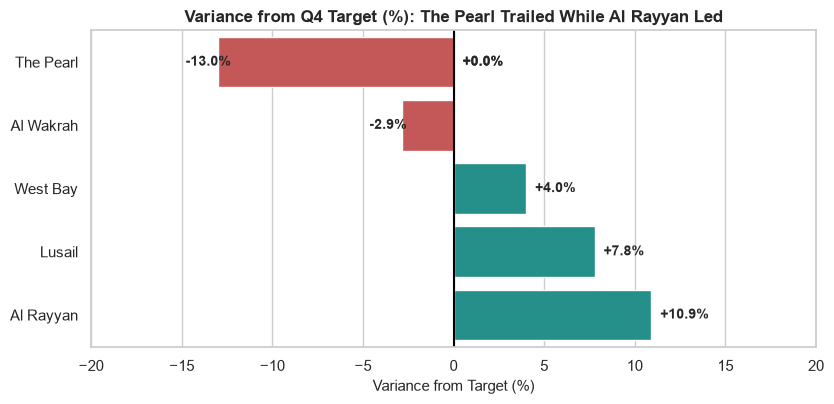

In [ ]:
# Sort zones by variance to highlight the biggest gap (Slide 39)
df_var_sorted = df.sort_values("pct_variance", ascending=True)

# --- Seaborn Implementation: Variance Diverging Bar Chart ---
plt.figure(figsize=(8.5, 4.2))

ax_var = sns.barplot(
    data=df_var_sorted, 
    x="pct_variance", 
    y="zone", 
    hue="miss", 
    palette={False: "#14A098", True: "#D64545"},
    dodge=False 
)

# Neutral zero line
ax_var.axvline(0, color="black", linewidth=1.5)
ax_var.set_xlim(-20, 20)

ax_var.set_title("Variance from Q4 Target (%): The Pearl Trailed While Al Rayyan Led", fontsize=12, weight="bold")
ax_var.set_xlabel("Variance from Target (%)", fontsize=11)
ax_var.set_ylabel("", fontsize=11)
ax_var.legend().remove()

# Add direct percentage labels
for p in ax_var.patches:
    val = p.get_width()
    offset = 0.5 if val >= 0 else -1.8
    ax_var.annotate(f"{val:+.1f}%", (val + offset, p.get_y() + p.get_height() / 2.), 
                    va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
# --- Plotly Express Implementation: Diverging Variance Bar Chart ---
fig_var = px.bar(
    df_var_sorted, 
    x="pct_variance", 
    y="zone", 
    orientation="h",
    color="miss",
    color_discrete_map={False: "#14A098", True: "#D64545"},
    text_auto="+.1f",
    title="Variance from Q4 Target (%): The Pearl Trailed While Al Rayyan Led",
    labels={"pct_variance": "Variance (%)", "zone": ""}
)

fig_var.add_vline(x=0, line_width=2, line_color="black")
fig_var.update_xaxes(range=[-20, 20])
fig_var.update_layout(showlegend=False)
fig_var.show()

### Interpretation for Variance Chart
- **Observation:** The Pearl (-13.0%) is immediately apparent as the sole severe negative bar, while Al Rayyan (+10.9%) and Lusail (+7.8%) stand out on the positive side.
- **Derived Insight:** Isolating the variance strips away distracting baseline volume and directs executive scrutiny straight to the operational exception.

## 4. Best Practices & Common Mistakes (Lecture Principles)
**Visualization Best Practices (Slide 39 & 46):**
- **Show the target explicitly:** Plotting actuals with no target benchmark cannot answer performance questions.
- **Use a consistent colour rule:** Reserve one colour for above target and one for below.
- **Label variance as both an absolute amount and a percentage** (-5.2M QAR, -13.0%).
- **Order regions by variance** so the biggest shortfall is impossible to miss.

**Common Mistakes & Misleading Designs:**
- **Moving the target mid-period:** Changing targets late in the cycle so every result appears as a success.
- **Red/Green as the sole signal:** Inaccessible to colour-blind readers; pair color with direct sign labels ($+$, $-$).
- **Treating a 1% miss and a 15% miss as equally serious:** Establish materiality thresholds.

## 5. Key Takeaways
1. **Actual-vs-target bar charts provide the clearest comparison** by combining actual result bars with distinct target marker ticks.
2. **Variance charts center on zero**, removing baseline volume and spotlighting under- and over-performance.
3. **Bullet charts pack three dimensions into minimal space:** actual value, target marker, and qualitative performance bands.
4. **Always state both amount and percentage variance** with clear, accessible color rules.